In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
import ad_tools.tools as tools
import normflows as nf
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
import numpy as np
import zuko as zk

/tmp/ipykernel_98874/1413042758.py:37: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.atlas.label(label="Internal", data=False, loc=0, ax=ax)
/home/xzcapask/atlas_ad_hllhc/env/lib/python3.10/site-packages/mplhep/exp_atlas.py:65: FutureWarning: kwarg `label` in function `exp_label()` is deprecated and will be removed: Use `text="..."` instead.
  return label_base.exp_label(**kwargs)


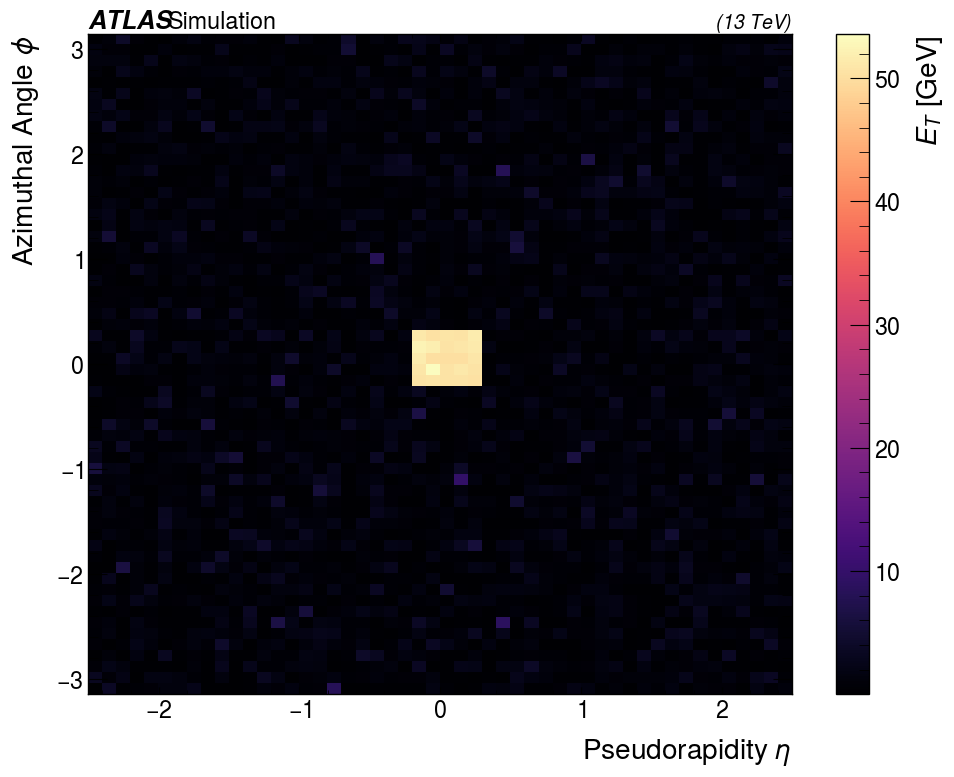

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

# Apply the official ATLAS style
hep.style.use(hep.style.ATLAS)

# 1. Generate Mock Calorimeter Data
n_eta, n_phi = 50, 60
eta_min, eta_max = -2.5, 2.5
phi_min, phi_max = -np.pi, np.pi

# Initialize an empty grid for the eta-phi space
# Note: shape is (y-axis, x-axis) -> (phi, eta)
calo_image = np.zeros((n_phi, n_eta))

# Simulate a localized energy deposit (e.g., a central jet)
jet_eta_idx, jet_phi_idx = 25, 30
calo_image[jet_phi_idx-2:jet_phi_idx+3, jet_eta_idx-2:jet_eta_idx+3] = 50.0 

# Add background electronic/pileup noise
calo_image += np.random.exponential(1.0, size=(n_phi, n_eta))

# 2. Create the Figure
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the 2D array using imshow
# extent=[left, right, bottom, top] maps pixels to physics coordinates
im = ax.imshow(calo_image, 
               extent=[eta_min, eta_max, phi_min, phi_max], 
               aspect='auto', 
               origin='lower', 
               cmap='magma') # 'magma' or 'viridis' handle zero-values cleanly

# 3. Add ATLAS Labels and Formatting
# loc=0 places the standard "ATLAS" label in the top-left corner
hep.atlas.label(label="Internal", data=False, loc=0, ax=ax)

# Configure the colorbar for transverse energy
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'$E_T$ [GeV]', loc='top')

# Set physics-standard axis labels
ax.set_xlabel(r'Pseudorapidity $\eta$')
ax.set_ylabel(r'Azimuthal Angle $\phi$')

plt.tight_layout()
plt.show()

In [9]:
class NFVAEEncoder(nn.Module):
    """
    NF-VAE Encoder 
    """
    def __init__(self, latent_dim = 256):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 6, out_channels = 8, kernel_size = 3, padding = (1,0))
        self.conv2 = nn.Conv2d(in_channels = 8, out_channels = 16, kernel_size = 3,padding = (1,0))
        self.conv3 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3,padding = (1,0))
        self.pool1 = nn.MaxPool2d(2, return_indices = True)
        self.pool2 = nn.MaxPool2d((5,2), return_indices = True)
        self.pool3 = nn.MaxPool2d((5,2), return_indices = True)
        self.flatten = nn.Flatten(start_dim = 1)
        self.mu = nn.Linear(256, latent_dim)
        self.logvar = nn.Linear(256, latent_dim)
        self.circular_padding = nn.CircularPad2d((1,1,0,0))




    
    def forward(self, input):
        # Convolutional Block 1
        output1 = self.circular_padding(input)
        output2 = self.conv1(output1)
        output3 = F.leaky_relu(output2)
        output4, indices1 = self.pool1(output3)



        # Convolutional Block 2
        output5 = self.circular_padding(output4)
        output6 = self.conv2(output5)
        output7 = F.leaky_relu(output6)
        output8 , indices2 = self.pool2(output7)



        # Convolutional Block 3
        output9 = self.circular_padding(output8)
        output10 = self.conv3(output9)
        output11 = F.leaky_relu(output10)
        output12, indices3 = self.pool3(output11)



        # Latent space mapping
        output13 = self.flatten(output12)
        mu = self.mu(output13)
        logvar = self.logvar(output13)
        return mu, logvar,indices1,indices2,indices3

In [3]:
class NFVAEDecoder(nn.Module):
    """
    NF-VAE Decoder.
    """
    def __init__(self, latent_dim = 256):
        super().__init__()
        self.linear = nn.Linear(latent_dim, 256)
    
        self.unpool1 = nn.MaxUnpool2d(kernel_size = (5,2))
        self.transconv1 = nn.ConvTranspose2d(in_channels = 32 , out_channels = 16 ,kernel_size = 3, padding = (1,2))
        


        self.unpool2 = nn.MaxUnpool2d(kernel_size = (5,2))
        self.transconv2 = nn.ConvTranspose2d(in_channels = 16 , out_channels = 8 ,kernel_size = 3, padding = (1,2))
        


        self.unpool3 = nn.MaxUnpool2d(kernel_size = 2)
        self.transconv3 = nn.ConvTranspose2d(in_channels = 8 , out_channels = 6 ,kernel_size = 3, padding = (1,2))        
        self.circular = nn.CircularPad2d((1,1,0,0))
        
    
    def forward(self, latent_vector,indices1, indices2, indices3):
        output1 = self.linear(latent_vector)
        output2 = F.leaky_relu(output1)
        output3 = torch.reshape(output2, shape = (-1,32,1,8))


        
        # Deconvolution Block 1
        output4 = self.unpool1(output3, indices3)
        output5 = self.circular(output4)
        output6 = self.transconv1(output5)
        output7 = F.leaky_relu(output6)



        # Deconvolution Block2
        output8 = self.unpool2(output7, indices2)
        output9 = self.circular(output8)
        output10 = self.transconv2(output9)
        output11 = F.leaky_relu(output10)



        # Deconvolution Block8
        output12 = self.unpool3(output11, indices1)
        output13 = self.circular(output12)
        output14 = self.transconv3(output13)
        output15 = F.relu(output14)
        return output15

In [10]:
class NFVAE(nn.Module):
    """
    NF-VAE using RealNVP
    """

    def __init__(self,latent_dim = 256):
        super().__init__()
        self.encoder = NFVAEEncoder(latent_dim = latent_dim)
        self.decoder = NFVAEDecoder(latent_dim = latent_dim)
        self.flow = zk.flows.NSF(features = latent_dim, transforms = 4, bins = 10, hidden_features = [latent_dim * 2, latent_dim * 2])
        self.epoch = 1

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std) 
        return mu + eps * std
    
    def forward(self, input):
        mu, logvar, indices1, indices2, indices3 = self.encoder(input)
        std = torch.exp(0.5 * logvar)
        z0 = self.reparameterise(mu, logvar)
        print(f"Epoch = {self.epoch}")
        print(f"z0 = {z0.max().item()}")


        q0 = torch.distributions.Normal(mu, std)

        # Flow transformation
        transform = self.flow().transform
        z = transform(z0)
        log_det = transform.log_abs_det_jacobian(z0, z)
        print(f"z = {z.max().item()}")
        print(f"log_Det = {log_det.max().item()}")

        # KL loss calculation
        p = torch.distributions.Normal(torch.zeros_like(z), torch.ones_like(z)) # Prior
        log_q0 = torch.sum(q0.log_prob(z0), dim=-1)
        log_p = torch.sum(p.log_prob(z), dim=-1)
        kld = log_q0 - log_det - log_p

        # Decoder Output
        output = self.decoder(z, indices1, indices2, indices3)

        self.epoch = self.epoch + 1
        return output,mu,logvar,kld,z

In [11]:
beta = np.ones(100)
model = NFVAE()

In [12]:
tools.train(project_name = "NFVAETest", model = model,
        weights_directory_path=f"/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE/weights",
        training_losses_directory_path=f"/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE/training_losses",
        beta = beta, epochs = 1, nf = True)

Starting Epoch 1
Epoch = 1
z0 = 6.1074066162109375
z = 6.1074066162109375
log_Det = 2.013774871826172
Epoch = 2
z0 = 10.747091293334961
z = 10.747091293334961
log_Det = 1.3863623142242432
Epoch = 3
z0 = 5.614632606506348
z = 5.614632606506348
log_Det = 4.065118789672852
Epoch = 4
z0 = 4.771522045135498
z = 4.758817195892334
log_Det = 2.261979103088379
Epoch = 5
z0 = 8.119367599487305
z = 8.119367599487305
log_Det = 2.4253249168395996
Epoch = 6
z0 = 9.742413520812988
z = 9.742413520812988
log_Det = 2.0749995708465576
Epoch = 7
z0 = 5.3988237380981445
z = 5.3988237380981445
log_Det = 2.5582568645477295
Epoch = 8
z0 = 5.225810527801514
z = 5.225810527801514
log_Det = 2.1461334228515625
Epoch = 9
z0 = 4.273289680480957
z = 4.277264595031738
log_Det = 2.729952573776245
Epoch = 10
z0 = 5.484643936157227
z = 5.484643936157227
log_Det = 1.5805176496505737
Epoch = 11
z0 = 4.503579139709473
z = 4.5145792961120605
log_Det = 2.2751054763793945
Epoch = 12
z0 = 5.872073650360107
z = 5.87207365036010

Training KL Loss,▁
Training Recon Loss,▁
Training Total Loss,▁
Validation KL Loss,▁
Validation Recon Loss,▁
Validation Total Loss,▁
total_norm,▁
Training KL Loss,232.61939
Training Recon Loss,8365.88978
Training Total Loss,8598.50917
Validation KL Loss,105.83587


In [13]:
tools.test(model = model,
        signal_acceptance_directory = f"/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE/signal_acceptance_rates",
        phi_invariance_study_directory=f"/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE/phi_invariance_study",
        latent_code_directory=f"/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE/latent_vectors",
        testing_losses_directory=f"/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE/testing_losses", nf=True)

Epoch = 1564
z0 = 2.838252544403076
z = 2.7598698139190674
log_Det = 46.81733703613281
Epoch = 1565
z0 = 3.0683698654174805
z = 2.838801860809326
log_Det = 41.80673599243164
Epoch = 1566
z0 = 3.9058539867401123
z = 3.723317861557007
log_Det = 42.17210006713867
Epoch = 1567
z0 = 8.296455383300781
z = 8.296455383300781
log_Det = 14.919443130493164
Epoch = 1568
z0 = 4.861070156097412
z = 4.873310089111328
log_Det = 42.977684020996094
Epoch = 1569
z0 = 3.597815990447998
z = 3.05043625831604
log_Det = 47.272132873535156
Epoch = 1570
z0 = 3.8266754150390625
z = 3.4960358142852783
log_Det = 46.919532775878906
Epoch = 1571
z0 = 3.1526596546173096
z = 3.1122279167175293
log_Det = 37.646488189697266
Epoch = 1572
z0 = 3.495610475540161
z = 3.4680848121643066
log_Det = 48.03912353515625
Epoch = 1573
z0 = 3.340500831604004
z = 3.0994772911071777
log_Det = 42.489173889160156
Epoch = 1574
z0 = 3.270045518875122
z = 2.856318473815918
log_Det = 46.5064811706543
Epoch = 1575
z0 = 3.926696300506592
z = 3

KeyboardInterrupt: 